In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import pandas as pd

# Replace with the actual path
file_path = "/kaggle/input/datasets/agneaybnair/logistic-regression-data/binary.dta"

data = pd.read_stata(file_path)


## Importing Required Libraries

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns

In [7]:
data.head

<bound method NDFrame.head of      admit    gre   gpa  rank
0      0.0  380.0  3.61   3.0
1      1.0  660.0  3.67   3.0
2      1.0  800.0  4.00   1.0
3      1.0  640.0  3.19   4.0
4      0.0  520.0  2.93   4.0
..     ...    ...   ...   ...
395    0.0  620.0  4.00   2.0
396    0.0  560.0  3.04   3.0
397    0.0  460.0  2.63   2.0
398    0.0  700.0  3.65   2.0
399    0.0  600.0  3.89   3.0

[400 rows x 4 columns]>

In [8]:
print(data.shape)

(400, 4)


In [9]:
data.isnull().sum()

admit    0
gre      0
gpa      0
rank     0
dtype: int64

In [8]:
data.columns

Index(['admit', 'gre', 'gpa', 'rank'], dtype='object')

In [9]:
data.describe

<bound method NDFrame.describe of      admit    gre   gpa  rank
0      0.0  380.0  3.61   3.0
1      1.0  660.0  3.67   3.0
2      1.0  800.0  4.00   1.0
3      1.0  640.0  3.19   4.0
4      0.0  520.0  2.93   4.0
..     ...    ...   ...   ...
395    0.0  620.0  4.00   2.0
396    0.0  560.0  3.04   3.0
397    0.0  460.0  2.63   2.0
398    0.0  700.0  3.65   2.0
399    0.0  600.0  3.89   3.0

[400 rows x 4 columns]>

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    float32
 1   gre     400 non-null    float32
 2   gpa     400 non-null    float32
 3   rank    400 non-null    float32
dtypes: float32(4)
memory usage: 6.4 KB


In [12]:
data.dtypes

admit    float32
gre      float32
gpa      float32
rank     float32
dtype: object

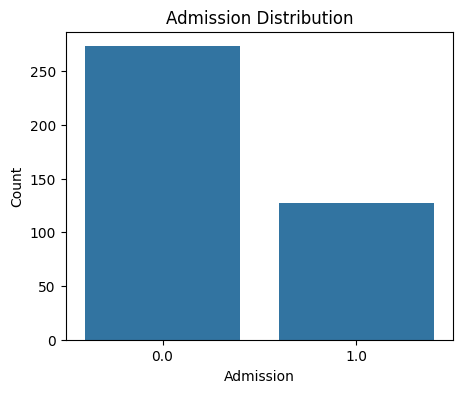

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(x='admit', data=data)

plt.title("Admission Distribution")
plt.xlabel("Admission")
plt.ylabel("Count")
plt.show()

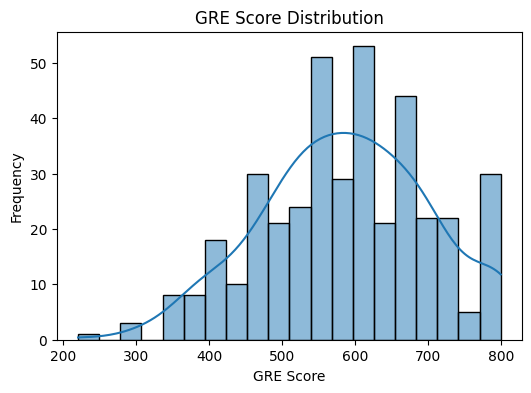

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(data['gre'], bins=20, kde=True)

plt.title("GRE Score Distribution")
plt.xlabel("GRE Score")
plt.ylabel("Frequency")
plt.show()

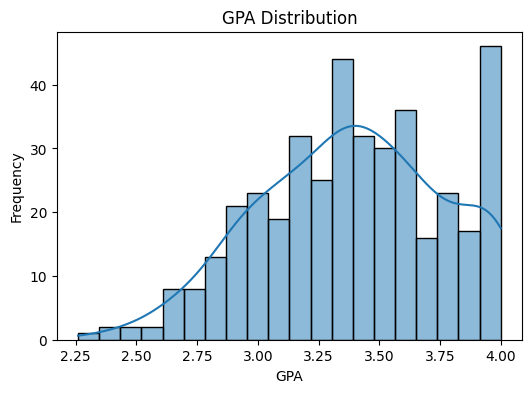

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(data['gpa'], bins=20, kde=True)

plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Frequency")
plt.show()

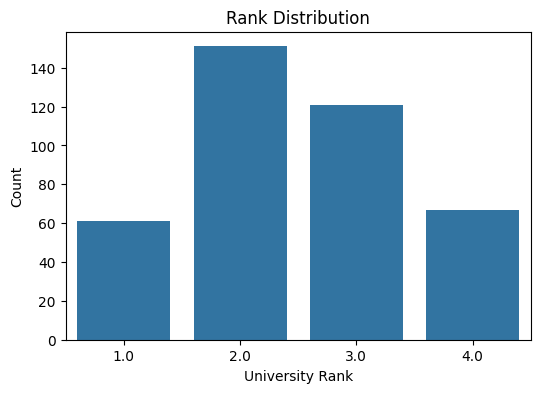

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='rank', data=data)

plt.title("Rank Distribution")
plt.xlabel("University Rank")
plt.ylabel("Count")
plt.show()

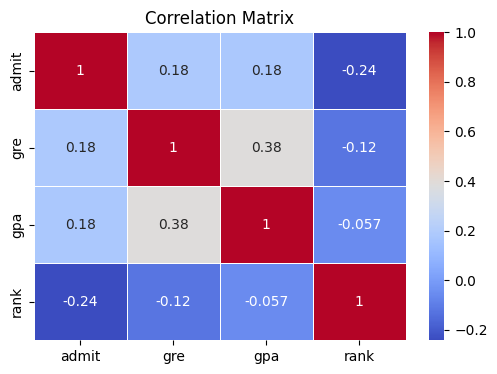

In [22]:
plt.figure(figsize=(6,4))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

In [24]:
data['admit'] = data['admit'].astype(int)
data['rank'] = data['rank'].astype(int)

In [25]:
# one hot encoding
data = pd.get_dummies(data,columns=['rank'],drop_first=True)

In [27]:
X = data.drop('admit', axis=1)
y = data['admit']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
model = LogisticRegression(max_iter=1000, random_state=42)

In [30]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [31]:
y_prob = model.predict_proba(X_test)[:, 1]
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head(10))

   Actual  Predicted
0       0          0
1       0          1
2       1          0
3       0          0
4       0          0
5       1          0
6       0          0
7       1          0
8       0          0
9       1          1
